In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/healthcare_data_for_task.csv")

In [4]:
df.head()

,Patient_ID,Age,Gender,Blood_Type,Medical_Condition,Medical_Code,Date_of_Admission,Discharge_Date,Admission_Type,Billing_Amount
0,P0001,47,Male,AB+,Heart Disease,HEA004,2025-05-10,2025-05-16,Emergency,23218.31
1,P0002,62,Female,AB-,Diabetes,DIA001,2025-12-31,2026-01-02,Emergency,47010.56
2,P0003,36,Male,AB-,Heart Disease,HEA004,2025-11-10,2025-11-27,Emergency,39619.01
3,P0004,51,Male,A+,Heart Disease,HEA004,2023-05-02,2023-05-07,Elective,35963.71
4,P0005,30,Male,A+,Diabetes,DIA001,2024-04-11,2024-04-17,Urgent,64615.93


In [5]:
df.shape

(1000, 10)

In [6]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition',
       'Medical_Code', 'Date_of_Admission', 'Discharge_Date', 'Admission_Type',
       'Billing_Amount'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   object 
 3   Blood_Type         1000 non-null   object 
 4   Medical_Condition  1000 non-null   object 
 5   Medical_Code       970 non-null    object 
 6   Date_of_Admission  1000 non-null   object 
 7   Discharge_Date     1000 non-null   object 
 8   Admission_Type     1000 non-null   object 
 9   Billing_Amount     1000 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 78.3+ KB


In [8]:
df['Age']
df['Medical_Code']

,Medical_Code
0,HEA004
1,DIA001
2,HEA004
3,HEA004
4,DIA001
...,...
995,DIA001
996,DIA001
997,DIA001
998,DIA001


In [9]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Type,0
Medical_Condition,0
Medical_Code,30
Date_of_Admission,0
Discharge_Date,0
Admission_Type,0
Billing_Amount,0


In [10]:
df['Medical_Code']=df['Medical_Code'].fillna('Unknown')

In [11]:
df['Admission_Code']=(
    df['Admission_Type']
    .str.strip()
    .str.title()
)

In [12]:
df['Admission_Type'].unique()

array(['Emergency', 'Elective', 'Urgent', 'urgent', ' Elective ',
       ' Emergency ', ' Urgent ', 'ELECTIVE', 'elective', 'URGENT',
       'emergency', 'EMERGENCY'], dtype=object)

In [13]:
df['Admission_Type'].value_counts()

,count
Admission_Type,
Emergency,375
Elective,353
Urgent,242
elective,6
ELECTIVE,5
Elective,4
urgent,3
Emergency,3
Urgent,3


In [14]:
df['Date_of_Admission']=pd.to_datetime(
    df['Date_of_Admission']
)

In [15]:
df['Discharge_Date']=pd.to_datetime(
    df['Discharge_Date']
)

In [16]:
df['Date_of_Admission'].dt.year

,Date_of_Admission
0,2025
1,2025
2,2025
3,2023
4,2024
...,...
995,2023
996,2025
997,2023
998,2023


In [17]:
df['Date_of_Admission'].dt.month

,Date_of_Admission
0,5
1,12
2,11
3,5
4,4
...,...
995,3
996,4
997,5
998,2


In [18]:
df['Date_of_Admission'].dt.date

,Date_of_Admission
0,2025-05-10
1,2025-12-31
2,2025-11-10
3,2023-05-02
4,2024-04-11
...,...
995,2023-03-16
996,2025-04-17
997,2023-05-08
998,2023-02-11


In [19]:
df['Stay_Days']=(
    df['Discharge_Date']
    -df['Date_of_Admission']
).dt.days

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient_ID         1000 non-null   object        
 1   Age                1000 non-null   int64         
 2   Gender             1000 non-null   object        
 3   Blood_Type         1000 non-null   object        
 4   Medical_Condition  1000 non-null   object        
 5   Medical_Code       1000 non-null   object        
 6   Date_of_Admission  1000 non-null   datetime64[ns]
 7   Discharge_Date     1000 non-null   datetime64[ns]
 8   Admission_Type     1000 non-null   object        
 9   Billing_Amount     1000 non-null   float64       
 10  Admission_Code     1000 non-null   object        
 11  Stay_Days          1000 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(7)
memory usage: 93.9+ KB


In [21]:
df['Billing_Amount'].describe()

,Billing_Amount
count,1000.000000
mean,77117.515720
std,41955.242269
min,5568.160000
25%,40318.785000
50%,77293.900000
75%,113089.267500
max,149921.800000


In [22]:
df.groupby('Medical_Condition')['Age'].mean()

,Age
Medical_Condition,
Arthritis,52.674641
Asthma,49.919598
Diabetes,53.130653
Heart Disease,52.180995
Hypertension,51.395349


In [24]:
pd.crosstab(
    df['Medical_Condition'],
    df['Gender']
)

Gender,Female,Male
Medical_Condition,,
Arthritis,95,114
Asthma,101,98
Diabetes,110,89
Heart Disease,104,117
Hypertension,80,92


<Axes: xlabel='Admission_Type'>

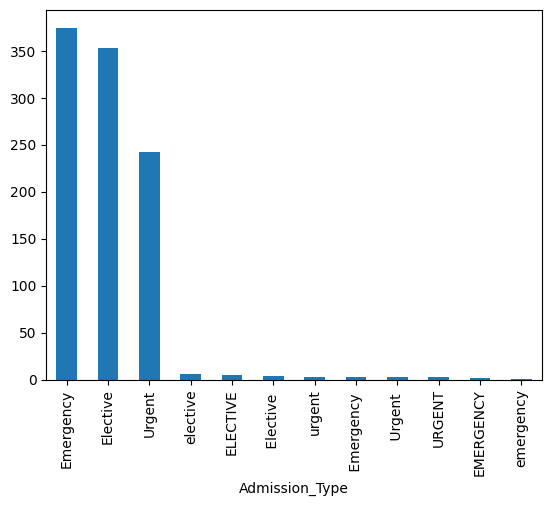

In [25]:
df['Admission_Type'].value_counts().plot(kind='bar')